# **Proyecto: Análisis estadístico sobre hábitos saludables en jóvenes universitarios**

# LECCIÓN 1 — Método científico y estadística

**1. Definir el problema de investigación**

Analizar si los hábitos de sueño, alimentación y actividad física tienen relación con el bienestar estudiantil(medido como nivel de energía).

**2. Formular hipótesis nula y alternativa**

Hipótesis nula (H₀):
No existe relación entre las horas de sueño, la alimentación y la actividad física con el nivel de energía de los estudiantes universitarios.

Hipótesis alternativa (H₁):
Existe una relación significativa entre las horas de sueño, la alimentación y la actividad física con el nivel de energía de los estudiantes universitarios.

**3. Identificar variables**

Variables cuantitativas (numéricas):

- Horas de sueño por noche

- Minutos de ejercicio por semana

- Nivel de energía 

- Edad

Variables cualitativas (categóricas):

- Género (Masculino / Femenino/ Otro)

- Calidad de alimentación (Buena / Regular / Mala)

**4. Método científico**

Se selecionó el método científico cuantitativo, porque buscamos relaciones entre variables y para ello se utilizarán herramientas estadísticas para evaluar las hipótesis planteadas.

En nuestro caso, tendríamos como variable objetivo Nivel_energía, así tenemos que:

- Variable dependiente (Y) : Nivel_energia

- Variables explicativas (X):  Horas_sueno, Ejercicio_min_semana, Calidad_alimentacion

- Variables de control: edad, genero


**5.Diseño preliminar del estudio**

Este es un estudio observacional, consideramos a nuestra población como el dataset creado de 150 estudiantes, del cual se tomara una muestra de 100 estudiantes universitarios. También, se destaca que las submuestras extraídas  serán utilizadas para analizar el comportamiento muestral y aplicar el Teorema del Límite Central.

En un caso real esta muestra de 100 estudiantes podría venir de una encuesta.

**Dataset creado, se considera nuestra población**

In [605]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# para reproducibilidad
np.random.seed(42)
n = 150   # tamaño de la población usamos 150 

# Variables cuantitativas
#Para evitar valores irreales se ocupará clip() que limitará los valores
edad = np.random.randint(18, 30, n)

horas_sueno = np.random.normal(7, 1.5, n)
horas_sueno = np.clip(horas_sueno, 3, 10)

ejercicio = np.random.normal(120, 60, n)
ejercicio = np.clip(ejercicio, 0, 400)

energia = np.random.normal(6, 2, n)
energia = np.clip(energia, 1, 10)

# Variables cualitativas
# En la variable alimentación se aplica p: probabilidad para seleccionar los valores
genero = np.random.choice(["Masculino", "Femenino", "Otro"], n)

alimentacion = np.random.choice(
    ["Buena", "Regular", "Mala"],
    n,
    p=[0.4, 0.4, 0.2]
)


In [606]:
#Creación del dataframe
df = pd.DataFrame({
    "Edad": edad,
    "Horas_sueno": horas_sueno,
    "Ejercicio_min_semana": ejercicio,
     "Nivel_energia": energia,
    "Genero": genero,
    "Calidad_alimentacion": alimentacion,
})

df.head()

,Edad,Horas_sueno,Ejercicio_min_semana,Nivel_energia,Genero,Calidad_alimentacion
0,24,7.130571,123.856801,7.744641,Masculino,Mala
1,21,6.551489,55.335313,6.366684,Masculino,Buena
2,28,7.137641,77.081777,10.000000,Otro,Regular
3,25,4.018647,160.775865,4.383403,Masculino,Regular
4,22,6.670492,76.178002,4.320556,Femenino,Regular


In [607]:
#Resumen estadístico del df creado
df.describe()

,Edad,Horas_sueno,Ejercicio_min_semana,Nivel_energia
count,150.000000,150.000000,150.000000,150.000000
mean,23.940000,7.047209,123.165210,5.859251
std,3.487716,1.366153,53.323912,2.054706
min,18.000000,4.018647,0.000000,1.396158
25%,21.000000,5.955181,82.975268,4.324942
50%,24.000000,7.141629,122.102460,5.803850
75%,27.000000,7.874298,157.970789,7.279489
max,29.000000,10.000000,249.190947,10.000000


Diccionario de variables:

| Variable             | Tipo         | Descripción                  |
| -------------------- | ------------ | ---------------------------- |
| Edad                 | Cuantitativa | Edad del estudiante          |
| Horas_sueno          | Cuantitativa | Horas de sueño por noche     |
| Ejercicio_min_semana | Cuantitativa | Minutos de ejercicio semanal |
| Nivel_energia        | Cuantitativa | Nivel de energía (1-10)      |
| Genero               | Cualitativa  | Masculino / Femenino / Otro  |
| Calidad_alimentacion | Cualitativa  | Buena / Regular / Mala       |

# LECCIÓN 2 — Probabilidad y estadística

**1. Explicar el tipo de muestreo a analizar**

Se utilizó un muestreo aleatorio simple, en el cual cada estudiante tiene la misma probabilidad de ser seleccionado. Se tomarán 100 observaciones, representando estudiantes universitarios con características diversas relacionadas con hábitos saludables.

**2. Simular diseño muestral: Vamos a obtener una muestra aleatoria del dataset creado**

In [608]:
muestra = df.sample(n=100, random_state=42)
muestra

,Edad,Horas_sueno,Ejercicio_min_semana,Nivel_energia,Genero,Calidad_alimentacion
73,23,7.445477,157.777731,3.881573,Masculino,Regular
18,22,6.411838,47.982216,8.358880,Masculino,Mala
118,24,7.259771,91.737702,9.046248,Otro,Buena
78,19,7.439609,118.745904,4.939485,Otro,Buena
76,21,5.979963,164.837616,4.028548,Otro,Regular
...,...,...,...,...,...,...
89,22,7.619171,121.260230,5.558061,Otro,Buena
8,24,5.787260,248.636645,4.481735,Femenino,Regular
13,21,7.769901,171.146000,4.846193,Otro,Regular
119,27,7.577976,133.922996,7.077820,Femenino,Buena


**3. Definir eventos aleatorios y su representación con árboles de probabilidad**

Un evento aleatorio es un resultado posible de un experimento aleatorio. 
En este estudio, el experimento consiste en seleccionar un estudiante universitario al azar de la muestra tomada.

Se definen los siguientes eventos:

Evento A: el estudiante duerme más de 7 horas

Evento B: el estudiante tiene nivel de energía mayor a 7

Evento C: el estudiante tiene buena alimentación

La probabilidad se calculó como la proporción de estudiantes que cumplen la condición respecto del total de la muestra. Esto se obtuvo dividiendo el número de casos favorables por el número total de observaciones.

In [609]:
#Probabilidad del evento A
evento_A = muestra["Horas_sueno"] > 7

prob_A = evento_A.mean()

prob_A

np.float64(0.53)

La probabilidad de que un estudiante seleccionado al azar duerma más de 7 horas es aproximadamente: 53%

In [610]:
#Probabilidad del evento B
evento_B = muestra["Nivel_energia"] > 7

prob_B = evento_B.mean()

prob_B

np.float64(0.29)

La probabilidad de que un estudiante seleccionado al azar presente un nivel de  energía mayor a 7 es aproximadamente: 29%

In [611]:
#Probabilidad del evento C
evento_C = muestra["Calidad_alimentacion"] == "Buena"

prob_C = evento_C.mean()

prob_C

np.float64(0.43)

La probabilidad de que un estudiante seleccionado al azar tenga una buena alimentación es aproximadamente: 43%

**4. Calcular probabilidades básicas de eventos**

Probabilidad de intersección:

Probabilidad de que un estudiante duerma más de 7 horas y tenga buena alimentación

In [612]:
interseccion = ((muestra["Horas_sueno"] > 7) & 
                (muestra["Calidad_alimentacion"] == "Buena"))

prob_interseccion = interseccion.mean()

prob_interseccion

np.float64(0.25)

La probabilidad de que un estudiante seleccionado al azar duerma más de 7 horas y tenga buena alimentación es aproximadamente: 25%.

Probabilidad de unión:

Dormir más de 7 horas o tener buena alimentación

In [613]:
union = ((muestra["Horas_sueno"] > 7) | 
         (muestra["Calidad_alimentacion"] == "Buena"))

prob_union = union.mean()

prob_union

np.float64(0.71)

La probabilidad de que un estudiante seleccionado al azar duerma más de 7 horas o tenga buena alimentación es aproximadamente: 71%.

Probabilidad complementaria:

Probabilidad de NO tener una alimentación buena.

In [614]:
prob_no_alimentacion_buena = 1 - prob_C

prob_no_alimentacion_buena

np.float64(0.5700000000000001)

La probabilidad de que un estudiante seleccionado al azar no tenga estrés alto es aproximadamente: 57%.

# LECCIÓN 3 — Distribución de probabilidad

**1. Identificar tipo de distribución de las variables**

| Variable             | Tipo                  | Distribución esperada |
| -------------------- | --------------------- | --------------------- |
| Horas_sueno          | Cuantitativa Continua | Normal                |
| Nivel_energia        | Cuantitativa Continua | Normal                |
| Ejercicio_min_semana | Cuantitativa Continua | Normal                |
| Calidad_alimentacion | Cualitativa Nominal   | Categórica no uniforme|

**2. Verificar distribución normal (visual)**

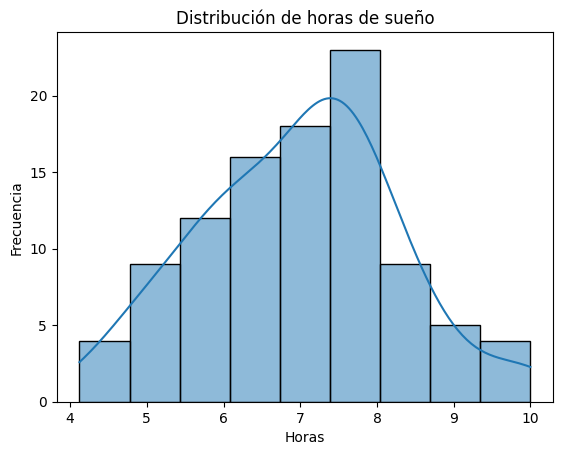

In [615]:
sns.histplot(muestra["Horas_sueno"], kde=True)
plt.title("Distribución de horas de sueño")
plt.xlabel("Horas")
plt.ylabel("Frecuencia")
plt.show()

In [616]:
print("Media:", muestra["Horas_sueno"].mean())
print("Mediana:", muestra["Horas_sueno"].median())

Media: 6.973303603465964
Mediana: 7.09659488856029


**3. Justificar la elección de las funciones de distribución:**
El gráfico muestra una forma parecida a una campana, la media y la mediana son parecidas(posible simetría) y además no se ve presencia de grandes sesgos, podemos decir que la variable Horas_sueno tiene una distribución aproximadamente normal. 

**4. Calcular probabilidades**: Probabilidad de que un estudiante duerma más de 8 horas.

In [617]:
media1 = muestra["Horas_sueno"].mean()
desviacion1 = muestra["Horas_sueno"].std()

print("Media:", media1)
print("Desviación estándar:", desviacion1)


Media: 6.973303603465964
Desviación estándar: 1.283740965658416


In [618]:
prob = 1 - norm.cdf(8, media1, desviacion1)

prob

np.float64(0.2119222855584899)

La probabilidad de que un estudiante duerma más de 8 horas es aproximadamente 21,19%.

**2. Verificar distribución normal (visual)**

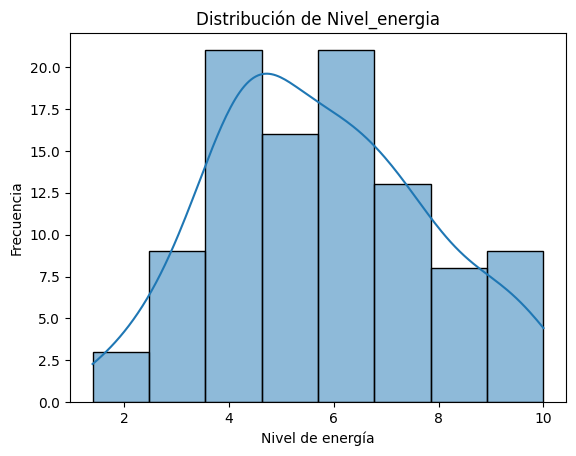

In [619]:
sns.histplot(muestra["Nivel_energia"], kde=True)
plt.title("Distribución de Nivel_energia")
plt.xlabel("Nivel de energía") 
plt.ylabel("Frecuencia")
plt.show()

In [620]:
print("Media:", muestra["Nivel_energia"].mean())
print("Mediana:", muestra["Nivel_energia"].median())

Media: 5.748694796826766
Mediana: 5.72970292349794


**3. Justificar la elección de las funciones de distribución:**
El gráfico muestra una forma parecida a una campana, la media y la mediana son parecidas(posible simetría) y además no se ve presencia de grandes sesgos, podemos decir que la variable Nivel_energía tiene una distribución aproximadamente normal. 

**4. Calcular probabilidades**: Probabilidad de que un estudiante tenga un nivel de energía menor a 7.

In [621]:
media2 = muestra["Nivel_energia"].mean()
desviacion2 = muestra["Nivel_energia"].std()

print("Media:", media2)
print("Desviación estándar:", desviacion2)

Media: 5.748694796826766
Desviación estándar: 2.018677464381449


In [622]:
prob = norm.cdf(7, media2, desviacion2)
prob

np.float64(0.732326289210266)

La probabilidad de que un estudiante tenga un nivel de energía menor a 7 es de 73.23%

**2. Verificar distribución normal (visual)**

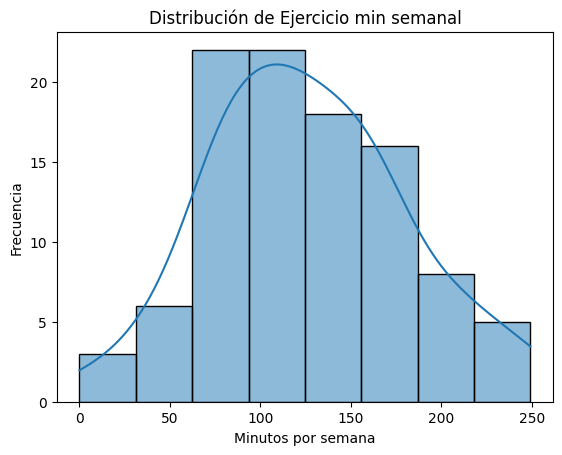

In [623]:
sns.histplot(muestra["Ejercicio_min_semana"], kde=True)
plt.title("Distribución de Ejercicio min semanal")
plt.xlabel("Minutos por semana") 
plt.ylabel("Frecuencia")
plt.show()

In [624]:
print("Media:", muestra["Ejercicio_min_semana"].mean())
print("Mediana:", muestra["Ejercicio_min_semana"].median())

Media: 125.92782122637558
Mediana: 120.68476385404145


**3. Justificar la elección de las funciones de distribución:**
El gráfico muestra una forma parecida a una campana, la media y la mediana son parecidas(posible simetría) y además no se ve presencia de grandes sesgos, podemos decir que la variable Ejercicio_min_semana tiene una distribución aproximadamente normal. 

**4. Calcular probabilidades**: Probabilidad de que un estudiante haga entre 30 y 50 min de ejercicio a la semana.

In [625]:
media3 = muestra["Ejercicio_min_semana"].mean()
desviacion3 = muestra["Ejercicio_min_semana"].std()

print("Media:", media3)
print("Desviación estándar:", desviacion3)

Media: 125.92782122637558
Desviación estándar: 54.74183307451789


In [626]:
from scipy.stats import norm

prob = norm.cdf(50, media3, desviacion3) - norm.cdf(30, media3, desviacion3)
prob

np.float64(0.04286307914450257)

La probabilidad de que un estudiante haga entre 30 y 50 min de ejercicio a la semana es de 4.29%

**2. Verificar distribución no uniforme (visual)**

In [627]:
#Frecuencia absoluta
muestra["Calidad_alimentacion"].value_counts().sort_index()

Calidad_alimentacion
Buena      43
Mala       20
Regular    37
Name: count, dtype: int64

In [628]:
#Frecuencia relativa
muestra["Calidad_alimentacion"].value_counts(normalize=True).sort_index()

Calidad_alimentacion
Buena      0.43
Mala       0.20
Regular    0.37
Name: proportion, dtype: float64

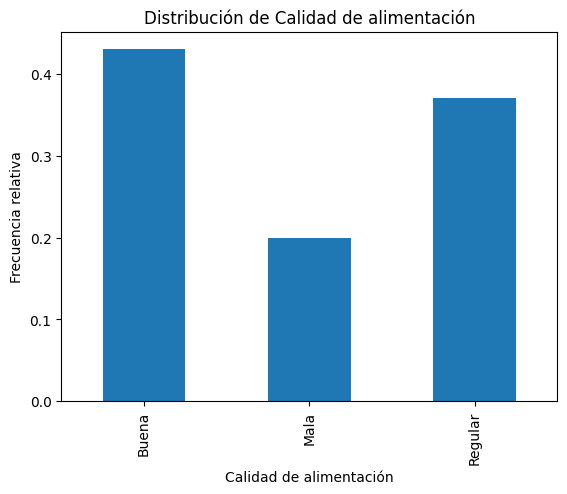

In [629]:
muestra["Calidad_alimentacion"].value_counts(normalize=True).sort_index().plot(kind="bar")

plt.title("Distribución de Calidad de alimentación")
plt.xlabel("Calidad de alimentación")
plt.ylabel("Frecuencia relativa")
plt.show()

**3. Justificar la elección de las funciones de distribución:**
La variable Calidad_alimentacion al ser cualitativa se hizo un gráfico de barras, dado que cada categoría  ["Buena", "Regular", "Mala"], fue creada con su respectiva probabilidad p=[0.4, 0.4, 0.2], resultó en una distribución categórica no uniforme. Las frecuencias observadas en el gráfico no son iguales a la creadas, esto es debido a la variabilidad muestral. Sin embargo, a medida que aumenta el tamaño de la muestra, las frecuencias relativas tienden a aproximarse a las probabilidades usadas al crear el dataset.

**4. Calcular probabilidades**: Probabilidad de que un estudiante tenga alimentación Mala.

In [630]:
(muestra["Calidad_alimentacion"] == "Mala").mean()

np.float64(0.2)

La probabilidad de que un estudiante tenga alimentación Mala es de 20%.

# LECCIÓN 4 — Método científico y estadística

**Generando distribuciones muestrales de media a partir del dataset simulado.**
- Tamaño de muestra n = 30
- Tamaño de muestra n = 80

Desviación estándar n=30: 0.3726349435764122
Desviación estándar n=80: 0.21919177749362198
Media poblacional: 5.859251358060898
Media medias n=30: 5.842172596458129
Media medias n=80: 5.85351416727479


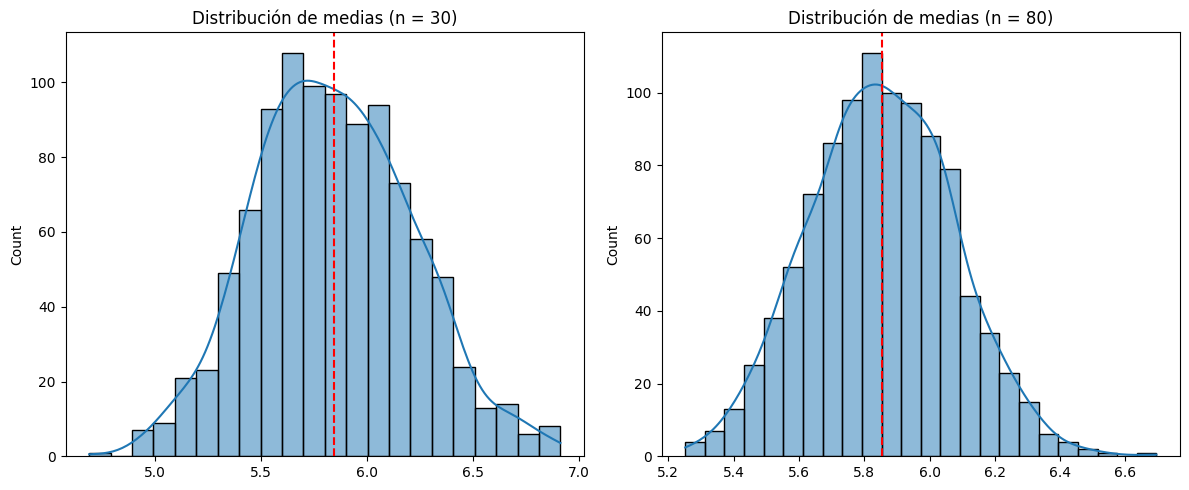

In [631]:
def simular_medias(n, repeticiones=1000):
    medias = []
    for _ in range(repeticiones):
        muestra_S = np.random.choice(df["Nivel_energia"], size=n)
        medias.append(np.mean(muestra_S))
    return medias

medias_n30 = simular_medias(30)
medias_n80 = simular_medias(80)

print("Desviación estándar n=30:", np.std(medias_n30))
print("Desviación estándar n=80:", np.std(medias_n80))
print("Media poblacional:", np.mean(df["Nivel_energia"]))
print("Media medias n=30:", np.mean(medias_n30))
print("Media medias n=80:", np.mean(medias_n80))

# Graficos
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.histplot(medias_n30, kde=True, ax=ax[0])
ax[0].set_title("Distribución de medias (n = 30)")

sns.histplot(medias_n80, kde=True, ax=ax[1])
ax[1].set_title("Distribución de medias (n = 80)")

ax[0].axvline(np.mean(medias_n30), color='red', linestyle='--')
ax[1].axvline(np.mean(medias_n80), color='red', linestyle='--')

plt.tight_layout()
plt.show()

**Comparando distribución poblacional con la muestra**

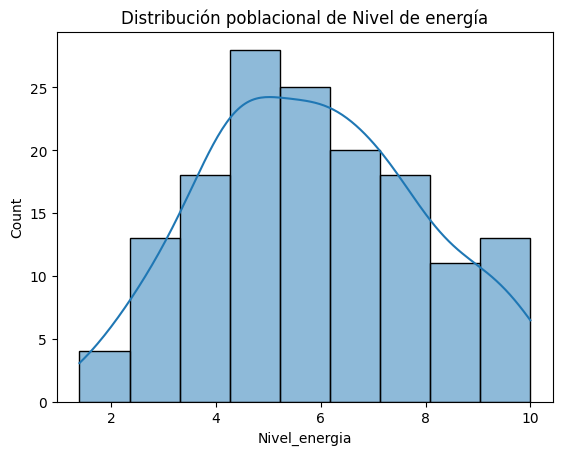

In [632]:
sns.histplot(df["Nivel_energia"], kde=True)
plt.title("Distribución poblacional de Nivel de energía")
plt.show()

In [633]:
media_poblacion = df["Nivel_energia"].mean()
desv_poblacion = df["Nivel_energia"].std()

media_poblacion, desv_poblacion

(np.float64(5.859251358060898), np.float64(2.0547056726044137))

5.859251358060898

**Verificar empíricamente el Teorema del Límite Central**
- Podemos observar que mediante la extracción repetida(1000 veces) de muestras aleatorias n=30 y n=80, los resultados muestran una forma aproximadamente normal, consistente con el Teorema del Límite Central, que establece que la distribución de las medias muestrales tiende a la normalidad a medida que aumenta el tamaño muestral.

**Analizar la dispersión de la media según tamaño muestral**
- También, pudimos observar que a medida que se aumenta el tamaño del n, el gráfico se vuelve más parecido a una distribución normal.

# LECCIÓN 5 — Inferencia e intervalos de confianza para la media.

**Calcular intervalos de confianza para la media de Nivel de energía**

Queremos estimar la media real del Nivel_energia de los estudiantes.
Suponiendo que no tengo la desviación poblacional, usaremos la función t student

In [634]:
#Tomaremos una muestra aleatoria de 90 estudiantes 
muestra_n90 = df.sample(n=90, random_state=42)
muestra_n90

media_n90 = muestra_n90["Nivel_energia"].mean()
desv_n90 = muestra_n90["Nivel_energia"].std()
n = 90
#grados de libertad
gl = n-1

In [635]:
from scipy.stats import t
import numpy as np

confianza = 0.90
alpha = 1 - confianza

t_critico = t.ppf(1 - alpha/2, gl)

error_estandar = desv_n90 / np.sqrt(n)

limite_inferior = media_n90 - t_critico * error_estandar
limite_superior = media_n90 + t_critico * error_estandar

limite_inferior, limite_superior

(np.float64(5.356130703757903), np.float64(6.062240704731702))

In [636]:
df["Nivel_energia"].mean()

np.float64(5.859251358060898)

Con un 90% de confianza podemos decir que el promedio poblacional de la variable Nivel_energia está dentro del intervalo (5.36 , 6.06), lo corroboramos sacando el promedio real poblacion(5.86) de la variable Nivel_energia en el Dataset creado.

In [637]:
from scipy.stats import t
import numpy as np

confianza = 0.95
alpha = 1 - confianza

t_critico = t.ppf(1 - alpha/2, gl)

error_estandar = desv_n90 / np.sqrt(n)

limite_inferior = media_n90 - t_critico * error_estandar
limite_superior = media_n90 + t_critico * error_estandar

limite_inferior, limite_superior

(np.float64(5.287135637801949), np.float64(6.131235770687656))

Con un 95% de confianza podemos decir que el promedio poblacional de la variable Nivel_energia está dentro del intervalo (5.29 , 6.13), lo corroboramos sacando el promedio real poblacion(5.86) de la variable Nivel_energia en el Dataset creado.

In [638]:
from scipy.stats import t
import numpy as np

confianza = 0.99
alpha = 1 - confianza

t_critico = t.ppf(1 - alpha/2, gl)

error_estandar = desv_n90 / np.sqrt(n)

limite_inferior = media_n90 - t_critico * error_estandar
limite_superior = media_n90 + t_critico * error_estandar

limite_inferior, limite_superior

(np.float64(5.150084615711161), np.float64(6.2682867927784445))

Con un 99% de confianza podemos decir que el promedio poblacional de la variable Nivel_energia está dentro del intervalo (5.15 , 6.27), lo corroboramos sacando el promedio real poblacion(5.86) de la variable Nivel_energia en el Dataset creado.

**Podemos ver que a medida que se aumenta el nivel de confianza se hace más pequeño el intervalo que debería tener dentro a la media poblacional, es decir se pierde precisión.**

**Evaluar el impacto del tamaño muestral sobre el ancho del intervalo**

In [639]:
#Tomaremos una muestra aleatoria de 40 estudiantes 
muestra_n40 = df.sample(n=40, random_state=42)
muestra_n40

media_n40 = muestra_n40["Nivel_energia"].mean()
desv_n40 = muestra_n40["Nivel_energia"].std()
n = 40
#grados de libertad
gl = n-1

In [640]:
from scipy.stats import t
import numpy as np

confianza = 0.90
alpha = 1 - confianza

t_critico = t.ppf(1 - alpha/2, gl)

error_estandar = desv_n40 / np.sqrt(n)

limite_inferior = media_n40 - t_critico * error_estandar
limite_superior = media_n40 + t_critico * error_estandar

limite_inferior, limite_superior

(np.float64(5.412971972102273), np.float64(6.378993289357815))

Con un 90% de confianza podemos decir que el promedio poblacional de la variable Nivel_energia está dentro del intervalo (5.41 , 6.38), lo corroboramos sacando el promedio real poblacion(5.86) de la variable Nivel_energia en el Dataset creado.
**En este caso la muestra fue de n= 40 estudiantes y podemos ver que el intervalo con n=90 era más acotado: (5.36 , 6.06), así podemos ver que a medida que disminuye el tamaño muestral se amplia el intervalo de confianza.**

**Calcular intervalos de confianza para la media de Ejercicio min semanal**

Queremos estimar la media real del Nivel_energia de los estudiantes.
Suponiendo que no tengo la desviación poblacional, usaremos la función t student

In [641]:
#Tomaremos una muestra aleatoria de 60 estudiantes 
muestra_n60 = df.sample(n=60, random_state=42)
muestra_n60

media_n60 = muestra_n60["Ejercicio_min_semana"].mean()
desv_n60 = muestra_n60["Ejercicio_min_semana"].std()
n = 60
#grados de libertad
gl = n-1

In [642]:
from scipy.stats import t
import numpy as np

confianza = 0.90
alpha = 1 - confianza

t_critico = t.ppf(1 - alpha/2, gl)

error_estandar = desv_n60 / np.sqrt(n)

limite_inferior = media_n60 - t_critico * error_estandar
limite_superior = media_n60 + t_critico * error_estandar

limite_inferior, limite_superior

(np.float64(108.89538412464813), np.float64(132.42768813116538))

In [643]:
df["Ejercicio_min_semana"].mean()

np.float64(123.16520991302673)

Con un 90% de confianza podemos decir que el promedio poblacional de la variable Ejercicio_min_semana está dentro del intervalo (108.9 , 132.43), lo corroboramos sacando el promedio real poblacional(123.17) de la variable Ejercicio_min_semana en el Dataset creado.

In [644]:
from scipy.stats import t
import numpy as np

confianza = 0.95
alpha = 1 - confianza

t_critico = t.ppf(1 - alpha/2, gl)

error_estandar = desv_n60 / np.sqrt(n)

limite_inferior = media_n60 - t_critico * error_estandar
limite_superior = media_n60 + t_critico * error_estandar

limite_inferior, limite_superior

(np.float64(106.57254447747616), np.float64(134.75052777833736))

Con un 95% de confianza podemos decir que el promedio poblacional de la variable Ejercicio_min_semana está dentro del intervalo (106.58 , 134.75), lo corroboramos sacando el promedio real poblacional(123.17) de la variable Ejercicio_min_semana en el Dataset creado.

In [645]:
from scipy.stats import t
import numpy as np

confianza = 0.99
alpha = 1 - confianza

t_critico = t.ppf(1 - alpha/2, gl)

error_estandar = desv_n60 / np.sqrt(n)

limite_inferior = media_n60 - t_critico * error_estandar
limite_superior = media_n60 + t_critico * error_estandar

limite_inferior, limite_superior

(np.float64(101.92011511047633), np.float64(139.40295714533718))

Con un 99% de confianza podemos decir que el promedio poblacional de la variable Ejercicio_min_semana está dentro del intervalo (101.92 , 139.40), lo corroboramos sacando el promedio real poblacional(123.17) de la variable Ejercicio_min_semana en el Dataset creado.

**Podemos ver que a medida que se aumenta el nivel de confianza se hace más pequeño el intervalo que debería tener dentro a la media poblacional, es decir se pierde precisión.**

**Evaluar el impacto del tamaño muestral sobre el ancho del intervalo**

In [646]:
#Tomaremos una muestra aleatoria de 35 estudiantes 
muestra_n35 = df.sample(n=35, random_state=42)
muestra_n35

media_n35 = muestra_n35["Ejercicio_min_semana"].mean()
desv_n35 = muestra_n35["Ejercicio_min_semana"].std()
n = 35
#grados de libertad
gl = n-1

In [647]:
from scipy.stats import t
import numpy as np

confianza = 0.90
alpha = 1 - confianza

t_critico = t.ppf(1 - alpha/2, gl)

error_estandar = desv_n35 / np.sqrt(n)

limite_inferior = media_n35 - t_critico * error_estandar
limite_superior = media_n35 + t_critico * error_estandar

limite_inferior, limite_superior

(np.float64(106.47974174861702), np.float64(136.84266800646432))

Con un 90% de confianza podemos decir que el promedio poblacional de la variable Ejercicio_min_semana está dentro del intervalo (106.48 , 136.84), lo corroboramos sacando el promedio real poblacional(123.17) de la variable Ejercicio_min_semana en el Dataset creado.
**En este caso la muestra fue de n= 35 estudiantes y podemos ver que el intervalo con n=60 era más acotado: (108.9 , 132.43), así podemos ver que a medida que disminuye el tamaño muestral se amplia el intervalo de confianza.**

# LECCIÓN 6 —  Test de significancia

**Realizar test de hipótesis para medias poblacionales**: Queremos probar que el nivel promedio de energía de los estudiantes es distinto de 7

- H₀ (nula): μ = 7
- H₁ (alternativa): μ ≠ 7
- Nivel de significancia: α = 0.05

Asumiendo que no conocemos la población, usamos función t
- x̄ = media muestral
- μ₀ = valor hipotético (7)
- s = desviación muestral
- n = tamaño muestra

In [648]:
from scipy.stats import t
import numpy as np
#Tomaremos una muestra aleatoria de 45 estudiantes 
muestra_n45 = df.sample(n=45, random_state=42)

mu_0 = 7

media = muestra_n45["Nivel_energia"].mean()
desv = muestra_n45["Nivel_energia"].std()
n = 45

t_stat = (media - mu_0) / (desv / np.sqrt(n))

p_valor = 2 * (1 - t.cdf(abs(t_stat), df=n-1))

print("t =", t_stat)
print("p-value =", p_valor)
print("¿Rechazo H0 al 5%? (alpha=0.05):", p_valor < 0.05)

t = -4.415383779840333
p-value = 6.463939700118715e-05
¿Rechazo H0 al 5%? (alpha=0.05): True


Como p<0,05 rechazamos H0, así tenemos que con un nivel de significancia del 5%, se rechaza la hipótesis nula. Existe evidencia estadística suficiente para concluir que el nivel promedio de energía es diferente de 7.

**Explicar errores tipo I y II en contexto del estudio**


Error Tipo I: Rechazar H₀ cuando en realidad es verdadera

Rechazar que el nivel promedio de Nivel de energía es 7 (μ = 7) cuando en realidad sí es 7.  
La probabilidad de cometer este error es = α (5%)


Error Tipo II: No rechazar H₀ cuando en realidad es falsa.

No rechazar la hipotesis nula H₀ cuando en realidad el nivel promedio de nivel de energía es distinto de 7 ( μ ≠ 7.)

**Realizar test de hipótesis para proporciones**: Queremos probar que más del 40% de los estudiantes tiene buena alimentación.

- H₀ (nula): p = 0.40
- H₁(alternativa): p > 0.40

Tenemos

- p̂ = proporción muestral
- p₀ = proporción hipotética (0.40)
- n = tamaño muestra (55 estudiantes)

A continuación, se verifica que se cumplen las condiciones de normalidad (np₀ ≥ 5 y n(1−p₀) ≥ 5, así podemos asumir que la distribución de la proporción muestral se aproxima a una distribución normal, y podemos utilizar el estadístico z.

In [649]:
n = 55
p0 = 0.40

cond1 = n * p0
cond2 = n * (1 - p0)

cond1, cond2

(22.0, 33.0)

In [650]:
from scipy.stats import t
import numpy as np
#Tomaremos una muestra aleatoria de 55 estudiantes 
muestra_n55 = df.sample(n=55, random_state=42)

#Calculando proporción muestral
p_hat = (muestra_n55["Calidad_alimentacion"] == "Buena").mean()
n = len(muestra)

p_hat

np.float64(0.43636363636363634)

In [651]:
import numpy as np
from scipy.stats import norm

p0 = 0.40

z = (p_hat - p0) / np.sqrt(p0 * (1 - p0) / n)

p_valor = 1 - norm.cdf(z)  # porque es unilateral derecha

print("z =", z)
print("p-value =", p_valor)
print("¿Rechazo H0 al 5%? (alpha=0.05):", p_valor < 0.05)

z = 0.7422696190252047
p-value = 0.22896199758084368
¿Rechazo H0 al 5%? (alpha=0.05): False


Como p≥ 0,05 no podemos rechazar H0, así tenemos que con un nivel de significancia del 5%, no se encontró evidencia suficiente para afirmar que más del 40% tenga buena alimentación.

Error Tipo I : Rechazar H₀ cuando en realidad es verdadera

Decidir que no hay evidencia suficiente para afirmar que más del 40% tiene buena alimentación cuando en realidad sí es mayor al 40% (por ejemplo 50%).

Error Tipo II: No rechazar H₀ cuando en realidad es falsa.

Decidir que no hay evidencia suficiente para afirmar que más del 40% tiene buena alimentación cuando en realidad sí es mayor al 40% (por ejemplo 50%).

**Conclusiones finales: Se considera que como mejora de este estudio, en una próxima oportunidad se considerará un análisis más profundo en el cual se relacionen las variables mencionadas inicialmente y se revisé que tanto se relacionan con el bienestar estudiantil.**